# DW STELLA-VITTA

In [36]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# EXTRACT

In [37]:
df = pd.read_excel('RESUMO PEDIDOS 11-2025.xlsx', sheet_name='Planilha6', decimal=',')
df

,FORNECEDOR,Código,Gramas,ITEM,Descrição,Quantidade,Valor Unitário,Valor Total,Quant banho prata,Quant banho dourado,VALOR UNIT + CUSTOS*
0,RE CASCIANO,BR 01312,0.700,BRINCO,BRINCO CORAÇÃO RESINADO FIXO 6 MM BX COLOR TIF...,5,4.43,22.15,3,2,NaN
1,RE CASCIANO,BR 01306,1.500,BRINCO,BRINCO GANCHO PEROLA CASTROADA 8 MM COM VENEZI...,5,3.80,19.00,3,2,NaN
2,RE CASCIANO,BR 01300,1.600,BRINCO,"BRINCO BORBOLETA COM LADO COLOR 1,2 CM IMP (CR...",5,9.90,49.50,3,2,NaN
3,RE CASCIANO,BR 01295,0.700,BRINCO,BRINCO FLOR TREVO ZIRC 8 MM IMP OS BRINCOS NAO...,5,9.50,47.50,3,2,NaN
4,RE CASCIANO,BR 01250,1.300,BRINCO,"BRINCO CORAÇÃO PUXADINHO ZIRC 1,1 CM IMP OS BR...",5,12.01,60.05,3,2,NaN
...,...,...,...,...,...,...,...,...,...,...,...
80,CAMILA CALSA,CR0720,0.005,COLAR,COLAR TRIPI 3D NA VENE,3,19.90,59.70,2,1,NaN
81,CAMILA CALSA,BL0082,0.008,BRACELETE,BRACELETE QUADRADO PASSA,3,18.90,56.70,2,1,NaN
82,CAMILA CALSA,BL0083,0.011,BRACELETE,BRACELETE QUADRADO TRI COR,3,27.90,83.70,2,1,NaN
83,CAMILA CALSA,AL0261,0.005,ANEL,ANEL TRIPI 3D,3,18.90,56.70,2,1,NaN


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   FORNECEDOR            85 non-null     object 
 1   Código                85 non-null     object 
 2   Gramas                85 non-null     float64
 3   ITEM                  85 non-null     object 
 4   Descrição             85 non-null     object 
 5   Quantidade            85 non-null     int64  
 6   Valor Unitário        85 non-null     float64
 7   Valor Total           85 non-null     float64
 8   Quant banho prata     85 non-null     int64  
 9   Quant banho dourado   85 non-null     int64  
 10  VALOR UNIT + CUSTOS*  0 non-null      float64
dtypes: float64(4), int64(3), object(4)
memory usage: 7.4+ KB


# Data Wrangling

In [39]:
df.columns

Index(['FORNECEDOR', 'Código', 'Gramas', 'ITEM', 'Descrição', 'Quantidade',
       'Valor Unitário', 'Valor Total', 'Quant banho prata',
       'Quant banho dourado', 'VALOR UNIT + CUSTOS*'],
      dtype='object')

In [40]:
df.rename(columns={'Código': 'CODIGO_COMPRA', 'Gramas': 'PESO(g)', 'ITEM': 'CATEGORIA', 'Descrição': 'DESCRICAO', 'Quantidade': 'QUANTIDADE',
'Valor Unitário': 'VALOR_UNIT', 'Valor Total': 'VALOR_TOTAL', 'Quant banho prata': 'BANHO_AG', 'Quant banho dourado': 'BANHO_AU'}, inplace=True)

In [41]:
df.describe()

,PESO(g),QUANTIDADE,VALOR_UNIT,VALOR_TOTAL,BANHO_AG,BANHO_AU,VALOR UNIT + CUSTOS*
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,0.0
mean,1.524729,4.470588,9.930776,39.097412,2.682353,1.788235,NaN
std,2.016820,0.946022,7.629854,25.757406,0.539218,0.619026,NaN
min,0.000000,3.000000,0.980000,4.900000,0.000000,1.000000,NaN
25%,0.024000,3.000000,3.800000,19.000000,2.000000,1.000000,NaN
50%,1.000000,5.000000,7.870000,38.700000,3.000000,2.000000,NaN
75%,1.900000,5.000000,15.900000,54.000000,3.000000,2.000000,NaN
max,10.000000,6.000000,29.900000,149.400000,3.000000,5.000000,NaN


In [42]:
df.groupby('CATEGORIA')['QUANTIDADE'].count().sort_values(ascending=True)

CATEGORIA
ANEL             1
ARGOLA           1
CONJUNTO         1
ESCAPULARIO      1
TORNOZELEIRA     1
GARGANTILHA      1
BRACELETE        2
RELICARIO        2
PULSEIRA         2
CHOKER           4
COLAR           14
PINGENTE        17
BRINCO          38
Name: QUANTIDADE, dtype: int64

In [43]:
df.groupby('CATEGORIA')['PESO(g)'].sum()

CATEGORIA
ANEL             0.005
ARGOLA          10.000
BRACELETE        0.019
BRINCO          49.358
CHOKER          13.900
COLAR           20.651
CONJUNTO         5.500
ESCAPULARIO      3.300
GARGANTILHA      2.900
PINGENTE        11.749
PULSEIRA         7.500
RELICARIO        3.020
TORNOZELEIRA     1.700
Name: PESO(g), dtype: float64

In [44]:
df['PESO(g)'].sum()

np.float64(129.602)

In [45]:
df.head(5)

,FORNECEDOR,CODIGO_COMPRA,PESO(g),CATEGORIA,DESCRICAO,QUANTIDADE,VALOR_UNIT,VALOR_TOTAL,BANHO_AG,BANHO_AU,VALOR UNIT + CUSTOS*
0,RE CASCIANO,BR 01312,0.7,BRINCO,BRINCO CORAÇÃO RESINADO FIXO 6 MM BX COLOR TIF...,5,4.43,22.15,3,2,NaN
1,RE CASCIANO,BR 01306,1.5,BRINCO,BRINCO GANCHO PEROLA CASTROADA 8 MM COM VENEZI...,5,3.80,19.00,3,2,NaN
2,RE CASCIANO,BR 01300,1.6,BRINCO,"BRINCO BORBOLETA COM LADO COLOR 1,2 CM IMP (CR...",5,9.90,49.50,3,2,NaN
3,RE CASCIANO,BR 01295,0.7,BRINCO,BRINCO FLOR TREVO ZIRC 8 MM IMP OS BRINCOS NAO...,5,9.50,47.50,3,2,NaN
4,RE CASCIANO,BR 01250,1.3,BRINCO,"BRINCO CORAÇÃO PUXADINHO ZIRC 1,1 CM IMP OS BR...",5,12.01,60.05,3,2,NaN


In [46]:
df_ag = df.copy()
df_ag['QUANTIDADE'] = df['BANHO_AG']
df_ag['BANHO'] = 'AG'
df_ag

,FORNECEDOR,CODIGO_COMPRA,PESO(g),CATEGORIA,DESCRICAO,QUANTIDADE,VALOR_UNIT,VALOR_TOTAL,BANHO_AG,BANHO_AU,VALOR UNIT + CUSTOS*,BANHO
0,RE CASCIANO,BR 01312,0.700,BRINCO,BRINCO CORAÇÃO RESINADO FIXO 6 MM BX COLOR TIF...,3,4.43,22.15,3,2,NaN,AG
1,RE CASCIANO,BR 01306,1.500,BRINCO,BRINCO GANCHO PEROLA CASTROADA 8 MM COM VENEZI...,3,3.80,19.00,3,2,NaN,AG
2,RE CASCIANO,BR 01300,1.600,BRINCO,"BRINCO BORBOLETA COM LADO COLOR 1,2 CM IMP (CR...",3,9.90,49.50,3,2,NaN,AG
3,RE CASCIANO,BR 01295,0.700,BRINCO,BRINCO FLOR TREVO ZIRC 8 MM IMP OS BRINCOS NAO...,3,9.50,47.50,3,2,NaN,AG
4,RE CASCIANO,BR 01250,1.300,BRINCO,"BRINCO CORAÇÃO PUXADINHO ZIRC 1,1 CM IMP OS BR...",3,12.01,60.05,3,2,NaN,AG
...,...,...,...,...,...,...,...,...,...,...,...,...
80,CAMILA CALSA,CR0720,0.005,COLAR,COLAR TRIPI 3D NA VENE,2,19.90,59.70,2,1,NaN,AG
81,CAMILA CALSA,BL0082,0.008,BRACELETE,BRACELETE QUADRADO PASSA,2,18.90,56.70,2,1,NaN,AG
82,CAMILA CALSA,BL0083,0.011,BRACELETE,BRACELETE QUADRADO TRI COR,2,27.90,83.70,2,1,NaN,AG
83,CAMILA CALSA,AL0261,0.005,ANEL,ANEL TRIPI 3D,2,18.90,56.70,2,1,NaN,AG


In [47]:
df_au = df.copy()
df_au['QUANTIDADE'] = df['BANHO_AU']
df_au['BANHO'] = 'AU'
df_au

,FORNECEDOR,CODIGO_COMPRA,PESO(g),CATEGORIA,DESCRICAO,QUANTIDADE,VALOR_UNIT,VALOR_TOTAL,BANHO_AG,BANHO_AU,VALOR UNIT + CUSTOS*,BANHO
0,RE CASCIANO,BR 01312,0.700,BRINCO,BRINCO CORAÇÃO RESINADO FIXO 6 MM BX COLOR TIF...,2,4.43,22.15,3,2,NaN,AU
1,RE CASCIANO,BR 01306,1.500,BRINCO,BRINCO GANCHO PEROLA CASTROADA 8 MM COM VENEZI...,2,3.80,19.00,3,2,NaN,AU
2,RE CASCIANO,BR 01300,1.600,BRINCO,"BRINCO BORBOLETA COM LADO COLOR 1,2 CM IMP (CR...",2,9.90,49.50,3,2,NaN,AU
3,RE CASCIANO,BR 01295,0.700,BRINCO,BRINCO FLOR TREVO ZIRC 8 MM IMP OS BRINCOS NAO...,2,9.50,47.50,3,2,NaN,AU
4,RE CASCIANO,BR 01250,1.300,BRINCO,"BRINCO CORAÇÃO PUXADINHO ZIRC 1,1 CM IMP OS BR...",2,12.01,60.05,3,2,NaN,AU
...,...,...,...,...,...,...,...,...,...,...,...,...
80,CAMILA CALSA,CR0720,0.005,COLAR,COLAR TRIPI 3D NA VENE,1,19.90,59.70,2,1,NaN,AU
81,CAMILA CALSA,BL0082,0.008,BRACELETE,BRACELETE QUADRADO PASSA,1,18.90,56.70,2,1,NaN,AU
82,CAMILA CALSA,BL0083,0.011,BRACELETE,BRACELETE QUADRADO TRI COR,1,27.90,83.70,2,1,NaN,AU
83,CAMILA CALSA,AL0261,0.005,ANEL,ANEL TRIPI 3D,1,18.90,56.70,2,1,NaN,AU


In [48]:
df = pd.concat([df_au, df_ag], ignore_index=True)
df.drop(columns=['BANHO_AG', 'BANHO_AU', 'VALOR_TOTAL'], inplace=True)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   FORNECEDOR            170 non-null    object 
 1   CODIGO_COMPRA         170 non-null    object 
 2   PESO(g)               170 non-null    float64
 3   CATEGORIA             170 non-null    object 
 4   DESCRICAO             170 non-null    object 
 5   QUANTIDADE            170 non-null    int64  
 6   VALOR_UNIT            170 non-null    float64
 7   VALOR UNIT + CUSTOS*  0 non-null      float64
 8   BANHO                 170 non-null    object 
dtypes: float64(3), int64(1), object(5)
memory usage: 12.1+ KB


In [50]:
df['PESO_TOTAL'] = round(df['PESO(g)'] * df['QUANTIDADE'], 2)
df

,FORNECEDOR,CODIGO_COMPRA,PESO(g),CATEGORIA,DESCRICAO,QUANTIDADE,VALOR_UNIT,VALOR UNIT + CUSTOS*,BANHO,PESO_TOTAL
0,RE CASCIANO,BR 01312,0.700,BRINCO,BRINCO CORAÇÃO RESINADO FIXO 6 MM BX COLOR TIF...,2,4.43,NaN,AU,1.40
1,RE CASCIANO,BR 01306,1.500,BRINCO,BRINCO GANCHO PEROLA CASTROADA 8 MM COM VENEZI...,2,3.80,NaN,AU,3.00
2,RE CASCIANO,BR 01300,1.600,BRINCO,"BRINCO BORBOLETA COM LADO COLOR 1,2 CM IMP (CR...",2,9.90,NaN,AU,3.20
3,RE CASCIANO,BR 01295,0.700,BRINCO,BRINCO FLOR TREVO ZIRC 8 MM IMP OS BRINCOS NAO...,2,9.50,NaN,AU,1.40
4,RE CASCIANO,BR 01250,1.300,BRINCO,"BRINCO CORAÇÃO PUXADINHO ZIRC 1,1 CM IMP OS BR...",2,12.01,NaN,AU,2.60
...,...,...,...,...,...,...,...,...,...,...
165,CAMILA CALSA,CR0720,0.005,COLAR,COLAR TRIPI 3D NA VENE,2,19.90,NaN,AG,0.01
166,CAMILA CALSA,BL0082,0.008,BRACELETE,BRACELETE QUADRADO PASSA,2,18.90,NaN,AG,0.02
167,CAMILA CALSA,BL0083,0.011,BRACELETE,BRACELETE QUADRADO TRI COR,2,27.90,NaN,AG,0.02
168,CAMILA CALSA,AL0261,0.005,ANEL,ANEL TRIPI 3D,2,18.90,NaN,AG,0.01


In [51]:
df['PESO_TOTAL'].sum()

np.float64(635.71)

In [52]:
df['VALOR_TOTAL'] = round(df['QUANTIDADE'] * df['VALOR_UNIT'], 2)

In [53]:
df['VALOR_TOTAL'].sum()

np.float64(3323.28)

# LOAD

### DF_FORNECEDOR

In [54]:
df_fornecedor = pd.DataFrame(df['FORNECEDOR'].unique())
df_fornecedor['COD_FORNECEDOR'] = range(1, len(df_fornecedor) + 1)
df_fornecedor['COD_FORNECEDOR'] = df_fornecedor['COD_FORNECEDOR'].apply(lambda x: str(x).zfill(2)).astype('str')
df_fornecedor.rename(columns={0: 'FORNECEDOR'}, inplace=True)
df_fornecedor = df_fornecedor[['COD_FORNECEDOR', 'FORNECEDOR']]
df_fornecedor

,COD_FORNECEDOR,FORNECEDOR
0,01,RE CASCIANO
1,02,DAVENZO
2,03,CAMILA CALSA


In [55]:
df_fornecedor.to_csv('fornecedore.csv', index=False)

### DF_CATEGORIA

In [56]:
df_categoria = pd.DataFrame(df['CATEGORIA'].unique())
df_categoria['COD_CATEGORIA'] = range(1, len(df_categoria) + 1)
df_categoria['COD_CATEGORIA'] = df_categoria['COD_CATEGORIA'].apply(lambda x: str(x).zfill(2)).astype('str')
df_categoria.rename(columns={0: 'CATEGORIA'}, inplace=True)
df_categoria = df_categoria[['COD_CATEGORIA', 'CATEGORIA']]
df_categoria

,COD_CATEGORIA,CATEGORIA
0,01,BRINCO
1,02,PINGENTE
2,03,ESCAPULARIO
3,04,CHOKER
4,05,GARGANTILHA
5,06,TORNOZELEIRA
6,07,COLAR
7,08,PULSEIRA
8,09,ARGOLA
9,10,CONJUNTO


In [57]:
df = pd.merge(df, df_fornecedor, on='FORNECEDOR', how='left')
df

,FORNECEDOR,CODIGO_COMPRA,PESO(g),CATEGORIA,DESCRICAO,QUANTIDADE,VALOR_UNIT,VALOR UNIT + CUSTOS*,BANHO,PESO_TOTAL,VALOR_TOTAL,COD_FORNECEDOR
0,RE CASCIANO,BR 01312,0.700,BRINCO,BRINCO CORAÇÃO RESINADO FIXO 6 MM BX COLOR TIF...,2,4.43,NaN,AU,1.40,8.86,01
1,RE CASCIANO,BR 01306,1.500,BRINCO,BRINCO GANCHO PEROLA CASTROADA 8 MM COM VENEZI...,2,3.80,NaN,AU,3.00,7.60,01
2,RE CASCIANO,BR 01300,1.600,BRINCO,"BRINCO BORBOLETA COM LADO COLOR 1,2 CM IMP (CR...",2,9.90,NaN,AU,3.20,19.80,01
3,RE CASCIANO,BR 01295,0.700,BRINCO,BRINCO FLOR TREVO ZIRC 8 MM IMP OS BRINCOS NAO...,2,9.50,NaN,AU,1.40,19.00,01
4,RE CASCIANO,BR 01250,1.300,BRINCO,"BRINCO CORAÇÃO PUXADINHO ZIRC 1,1 CM IMP OS BR...",2,12.01,NaN,AU,2.60,24.02,01
...,...,...,...,...,...,...,...,...,...,...,...,...
165,CAMILA CALSA,CR0720,0.005,COLAR,COLAR TRIPI 3D NA VENE,2,19.90,NaN,AG,0.01,39.80,03
166,CAMILA CALSA,BL0082,0.008,BRACELETE,BRACELETE QUADRADO PASSA,2,18.90,NaN,AG,0.02,37.80,03
167,CAMILA CALSA,BL0083,0.011,BRACELETE,BRACELETE QUADRADO TRI COR,2,27.90,NaN,AG,0.02,55.80,03
168,CAMILA CALSA,AL0261,0.005,ANEL,ANEL TRIPI 3D,2,18.90,NaN,AG,0.01,37.80,03


In [58]:
df_categoria.to_csv('categoria.csv', index=False)

### DF_PRODUTOS

In [59]:
df['INDEX'] = range(1, len(df) + 1)
df['INDEX'] = df['INDEX'].apply(lambda x: str(x).zfill(6))
df['SKU'] = df['COD_FORNECEDOR'].astype(str) + df['INDEX'].astype('str') + df['BANHO']
df_produtos = df[['SKU', 'DESCRICAO', 'PESO(g)']]

In [60]:
df_produtos.to_csv('produto.csv', index=False)

### DF_PEDIDOS

In [61]:
df = df[['SKU', 'DESCRICAO', 'PESO(g)', 'CATEGORIA', 'FORNECEDOR', 'CODIGO_COMPRA', 'QUANTIDADE', 'VALOR_UNIT', 'VALOR_TOTAL', 'PESO_TOTAL', 'BANHO']].copy()
df[['FRETE', 'GALVANICA', 'COTACAO_M', 'CAMADA', 'VERNIZ', 'SERVICO', 'BOLSA', 'CARTELA', 'EMBALAGEM', 'ETIQUETA', 'TINTA', 'IMPOSTO', 'TAXA_CREDITO', 'CARTAO_GARANTIA']] = 0.0
df

,SKU,DESCRICAO,PESO(g),CATEGORIA,FORNECEDOR,CODIGO_COMPRA,QUANTIDADE,VALOR_UNIT,VALOR_TOTAL,PESO_TOTAL,...,VERNIZ,SERVICO,BOLSA,CARTELA,EMBALAGEM,ETIQUETA,TINTA,IMPOSTO,TAXA_CREDITO,CARTAO_GARANTIA
0,01000001AU,BRINCO CORAÇÃO RESINADO FIXO 6 MM BX COLOR TIF...,0.700,BRINCO,RE CASCIANO,BR 01312,2,4.43,8.86,1.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,01000002AU,BRINCO GANCHO PEROLA CASTROADA 8 MM COM VENEZI...,1.500,BRINCO,RE CASCIANO,BR 01306,2,3.80,7.60,3.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,01000003AU,"BRINCO BORBOLETA COM LADO COLOR 1,2 CM IMP (CR...",1.600,BRINCO,RE CASCIANO,BR 01300,2,9.90,19.80,3.20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,01000004AU,BRINCO FLOR TREVO ZIRC 8 MM IMP OS BRINCOS NAO...,0.700,BRINCO,RE CASCIANO,BR 01295,2,9.50,19.00,1.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,01000005AU,"BRINCO CORAÇÃO PUXADINHO ZIRC 1,1 CM IMP OS BR...",1.300,BRINCO,RE CASCIANO,BR 01250,2,12.01,24.02,2.60,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,03000166AG,COLAR TRIPI 3D NA VENE,0.005,COLAR,CAMILA CALSA,CR0720,2,19.90,39.80,0.01,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
166,03000167AG,BRACELETE QUADRADO PASSA,0.008,BRACELETE,CAMILA CALSA,BL0082,2,18.90,37.80,0.02,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
167,03000168AG,BRACELETE QUADRADO TRI COR,0.011,BRACELETE,CAMILA CALSA,BL0083,2,27.90,55.80,0.02,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
168,03000169AG,ANEL TRIPI 3D,0.005,ANEL,CAMILA CALSA,AL0261,2,18.90,37.80,0.01,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [62]:
df.to_csv('pedido_raw.csv', index=False)

# VIEW

## FORNECEDORES

In [63]:
quantidade_fornecedor = df.groupby('FORNECEDOR')['QUANTIDADE'].sum().sort_values(ascending=False)
quantidade_fornecedor

FORNECEDOR
RE CASCIANO     250
CAMILA CALSA     90
DAVENZO          40
Name: QUANTIDADE, dtype: int64

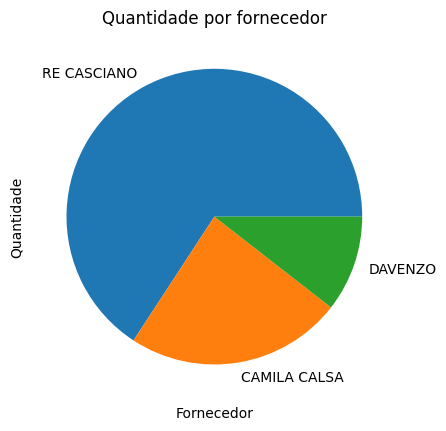

In [64]:
quantidade_fornecedor.plot(kind='pie', color='skyblue', title='Quantidade por fornecedor')
plt.xlabel('Fornecedor')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.show()

In [65]:
valor_total_fornecedor_mean = df.groupby('FORNECEDOR')['VALOR_TOTAL'].mean().sort_values(ascending=False)

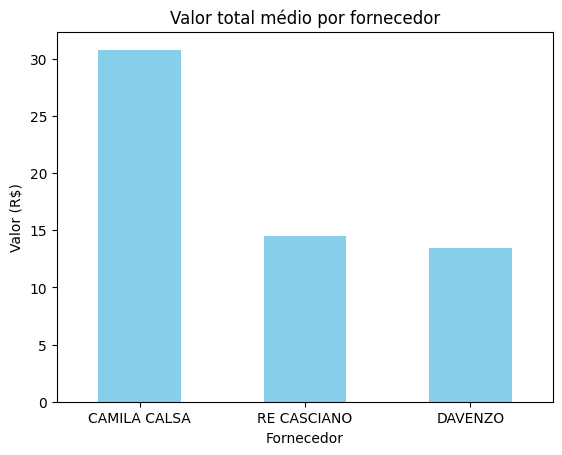

In [66]:
valor_total_fornecedor_mean.plot(kind='bar', color='skyblue', title='Valor total médio por fornecedor')
plt.xlabel('Fornecedor')
plt.ylabel('Valor (R$)')
plt.xticks(rotation=0)
plt.show()

## PRODUTO

In [67]:
valor_total_tipo = round(df.groupby('CATEGORIA')['VALOR_UNIT'].sum().sort_values(ascending=False),2)
valor_total_tipo

CATEGORIA
BRINCO          575.02
COLAR           426.45
PINGENTE        322.10
BRACELETE        93.60
RELICARIO        73.60
CHOKER           47.44
ANEL             37.80
PULSEIRA         28.00
ESCAPULARIO      24.54
TORNOZELEIRA     18.38
CONJUNTO         16.46
GARGANTILHA      16.32
ARGOLA            8.52
Name: VALOR_UNIT, dtype: float64

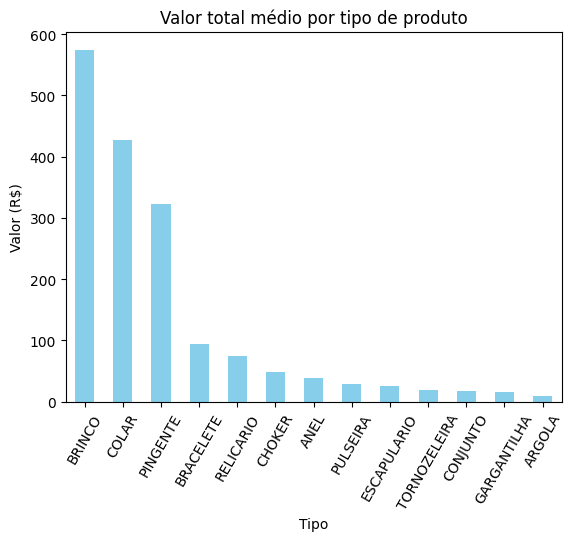

In [68]:
valor_total_tipo.plot(kind='bar', color='skyblue', title='Valor total médio por tipo de produto')
plt.xlabel('Tipo')
plt.ylabel('Valor (R$)')
plt.xticks(rotation=60)
plt.show()

In [69]:
peso_medio_tipo = df.groupby('CATEGORIA')['PESO(g)'].mean().sort_values(ascending=True)
peso_medio_tipo

CATEGORIA
ANEL             0.005000
BRACELETE        0.009500
PINGENTE         0.691118
BRINCO           1.298895
COLAR            1.475071
RELICARIO        1.510000
TORNOZELEIRA     1.700000
GARGANTILHA      2.900000
ESCAPULARIO      3.300000
CHOKER           3.475000
PULSEIRA         3.750000
CONJUNTO         5.500000
ARGOLA          10.000000
Name: PESO(g), dtype: float64

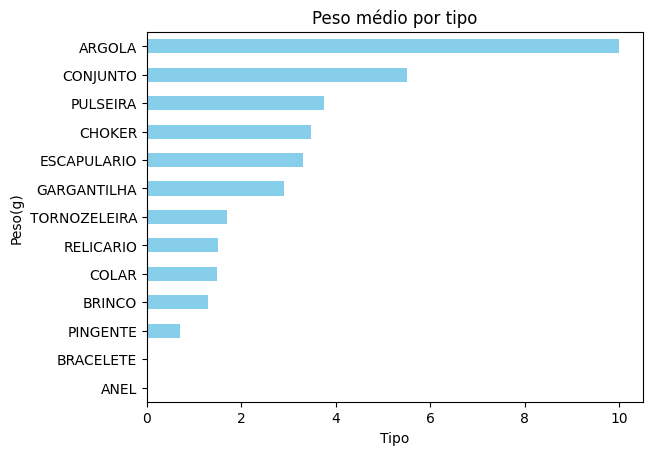

In [70]:
peso_medio_tipo.plot(kind='barh', color='skyblue', title='Peso médio por tipo')
plt.ylabel('Peso(g)')
plt.xlabel('Tipo')
plt.xticks(rotation=0)
plt.show()